In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 
pd.set_option('display.precision', 18)

In [4]:
be_3po_path = '/home/aldiyar/extrapolation/new-dataset/be_3po_test.csv'
be_3po = upload_basis(be_3po_path)
be_3po_err = upload_error(be_3po_path)
be_3po_init = be_3po.head(4)

In [5]:
be_3po_large = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_3Po.csv')
be_3po_large_init = be_3po_large[:-1]
be_3po_large_last = be_3po_large.tail(1)

In [6]:
be_3se_01 = upload_basis('/home/aldiyar/extrapolation/new-dataset/be_3se_01_test.csv')
be_3se_01_init = be_3se_01.head(4)
be_3se_01_err = upload_error('/home/aldiyar/extrapolation/new-dataset/be_3se_01_test.csv')

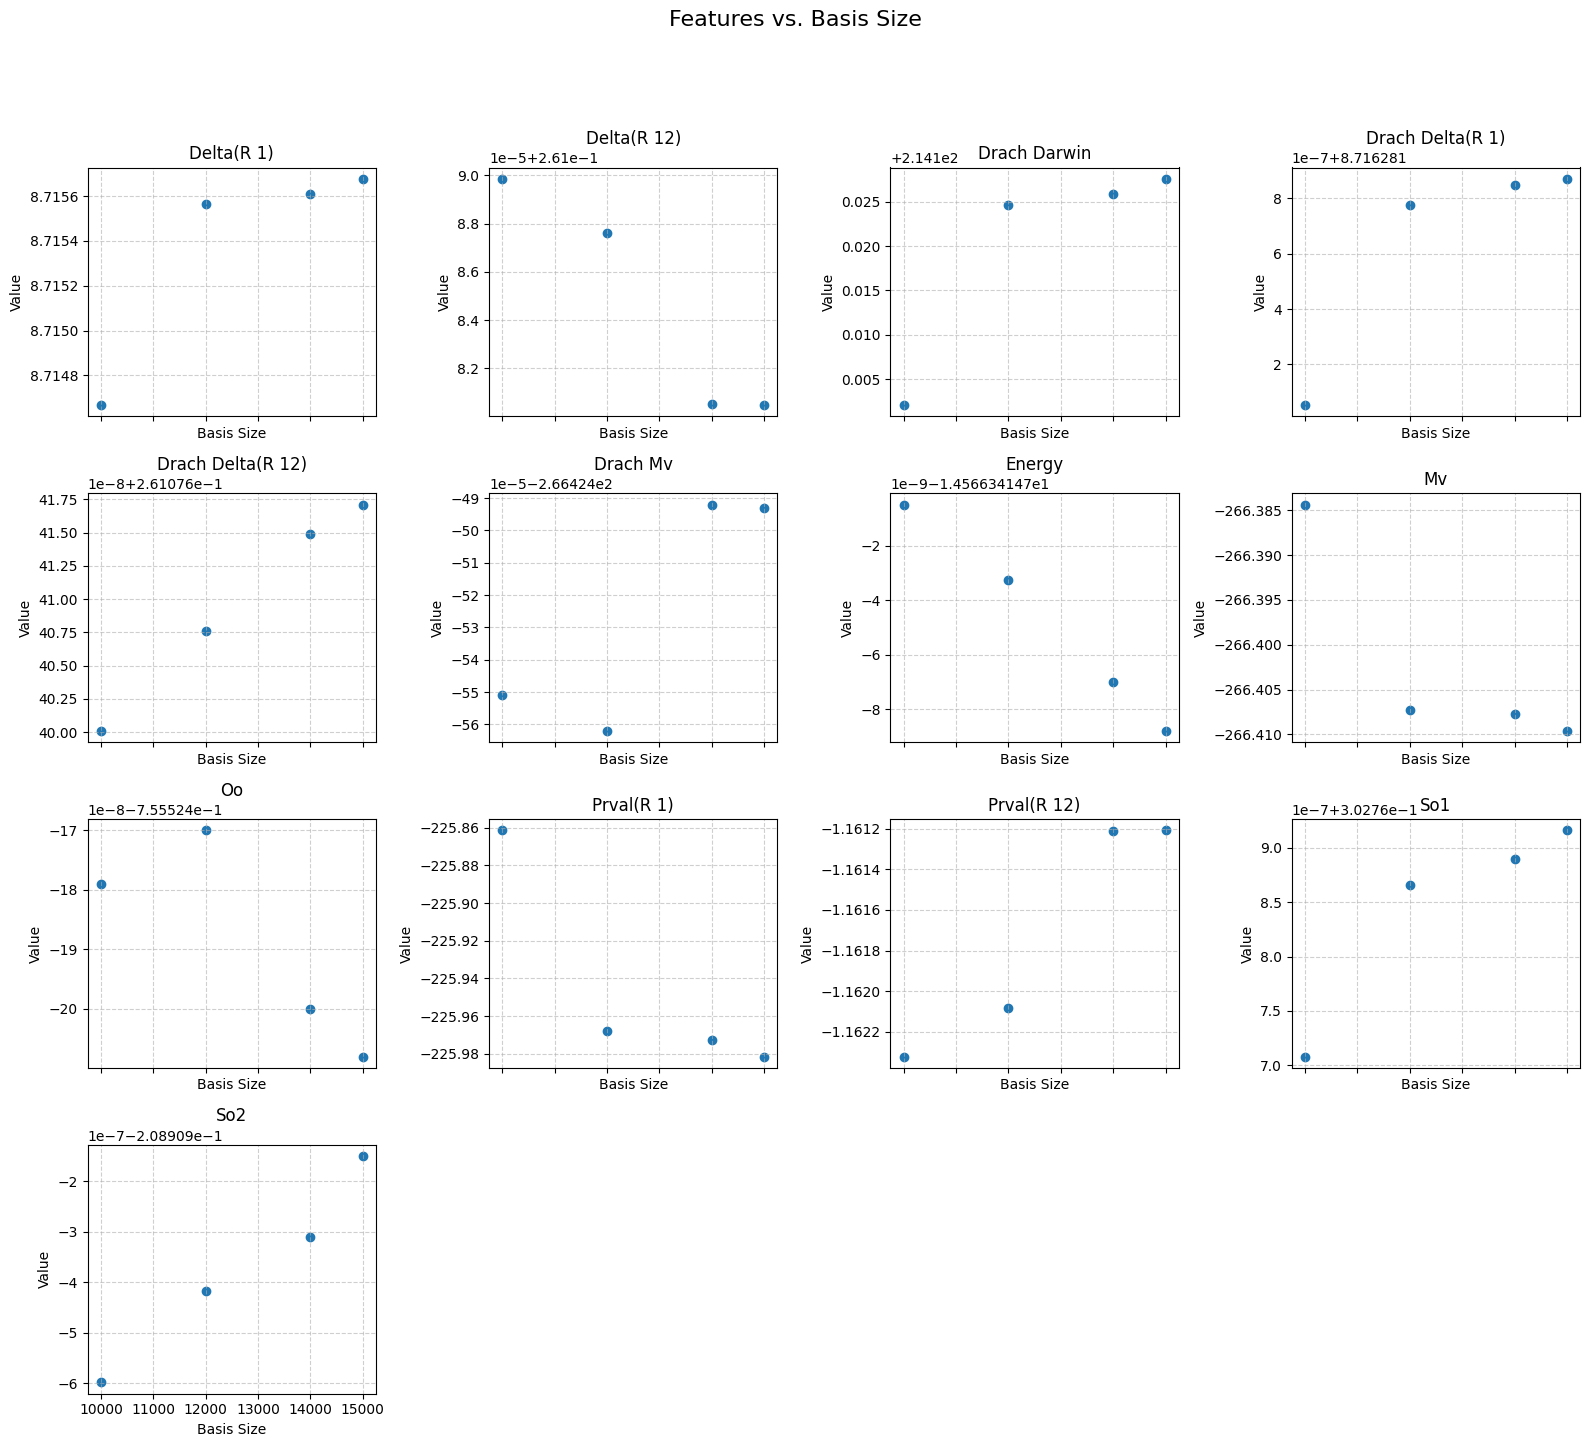

In [10]:
graph(be_3po_init)

In [ ]:

from scipy.optimize import least_squares, lsq_linear

class VarProIRLS:
    def __init__(self, df, x_col, y_col, err_df=None, b_init=None):
        self.raw_x = df[x_col].values.astype(float)
        self.raw_y = df[y_col].values.astype(float)
        self.x_col = x_col
        self.y_col = y_col
        self.err_df = err_df 
        
        # Sort data by X
        idx = np.argsort(self.raw_x)
        self.raw_x = self.raw_x[idx]
        self.raw_y = self.raw_y[idx]

        self.x_min = self.raw_x.min()
        self.x_max = self.raw_x.max()
        self.range_x = self.x_max - self.x_min
        if self.range_x == 0: 
            self.range_x = 1.0
        
        # --- IMPROVED TREND DETECTION ---
        # Instead of comparing just first/last points, we use the slope 
        # of a simple linear regression to determine global direction.
        slope, _ = np.polyfit(self.raw_x, self.raw_y, 1)
        self.is_increasing = slope > 0
        # --------------------------------

        self.override_b_init = b_init
        self.b_init = 1.0
        self.results = {}

    def _setup_model(self, model_type):
        self.model_type = model_type
        if self.model_type in ['power_law', 'sqrt_exponential']:
            safe_x = np.maximum(self.raw_x, self.x_max * 1e-6)
            self.t_scaled = safe_x / self.x_max
        else:
            self.t_scaled = (self.raw_x - self.x_min) / self.range_x
            
        if self.override_b_init is not None:
            self.b_init = self.override_b_init
        else:
            self.b_init = self._grid_search_initialization()

    def _get_A_bounds(self):
        """Only constrain A based on curve direction, C is unconstrained."""
        if self.is_increasing:
            # A must be negative for increasing curve approaching C from below
            lb = [-np.inf, -np.inf]
            ub = [np.inf, 0]
        else: 
            # A must be positive for decreasing curve approaching C from above
            lb = [-np.inf, 0]
            ub = [np.inf, np.inf]
        return lb, ub

    def _grid_search_initialization(self):
        grid_B = np.linspace(1, 100, 10000) 
        best_ssr = np.inf
        best_B = 1.0
        
        lb, ub = self._get_A_bounds()
        
        for b_val in grid_B: 
            phi = self._compute_basis(b_val, self.t_scaled)
            
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.inf
            
            if ssr < best_ssr:
                best_ssr = ssr
                best_B = b_val
                
        return best_B

    def _compute_basis(self, B, t):
        phi = np.zeros((len(t), 2))
        phi[:, 0] = 1.0
        if self.model_type == 'exponential':
            phi[:, 1] = np.exp(-B * t)
        elif self.model_type == 'sqrt_exponential':
            phi[:, 1] = np.exp(-B * np.sqrt(t))
        elif self.model_type == 'power_law': 
            phi[:, 1] = np.power(t, -B)
        return phi

    def _compute_model_weights(self, B, t):
        if self.model_type == 'exponential':
            w = np.exp(B * t)
        elif self.model_type == 'sqrt_exponential': 
            w = np.exp(B * np.sqrt(t))
        elif self.model_type == 'power_law': 
            t_safe = np.maximum(t, 1e-12)
            w = np.power(t_safe, B)

        w = w ** 2
        w = np.nan_to_num(w, nan=1.0, posinf=np.finfo(float).max, neginf=0.0)
        return w

    def _solve_varpro_step(self, weights, start_b=None):
        y_w = self.raw_y * np.sqrt(weights)
        if start_b is None:  
            start_b = self.b_init
        
        lb, ub = self._get_A_bounds()

        def residual_func(alpha_curr):
            phi = self._compute_basis(alpha_curr[0], self.t_scaled)
            phi_w = phi * np.sqrt(weights)[:, np.newaxis]
            res_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
            y_model = np.dot(phi, res_lin.x)
            return (self.raw_y - y_model) * np.sqrt(weights)

        res_opt = least_squares(residual_func, x0=[start_b], bounds=(1e-6, np.inf), 
                                method='trf', loss='soft_l1')
        
        best_B = res_opt.x[0]
        phi = self._compute_basis(best_B, self.t_scaled)
        phi_w = phi * np.sqrt(weights)[:, np.newaxis]
        final_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
        
        return best_B, final_lin.x[0], final_lin.x[1]

    def fit_irls(self, max_iter=100, tol=1e-8, damping=0.5, models=None, verbose=True, compute_uq=True):
        if models is None: 
            models = ['exponential', 'sqrt_exponential', 'power_law']
        
        for model in models: 
            self._setup_model(model)
            if verbose:
                print(f"\n--- Fitting Model: {self.model_type} ---")
                print(f"{'Iter':<5} | {'B (Decay)':<12} | {'C (Asymptote)':<15} | {'Weight Ratio':<25}")
                print("-" * 65)

            current_weights = np.ones(len(self.raw_x))
            prev_C = np.inf
            current_B_guess = self.b_init
            
            final_B, final_C, final_A = 0, 0, 0

            for k in range(max_iter):
                B, C, A = self._solve_varpro_step(current_weights, start_b=current_B_guess)
                current_B_guess = B
                final_B, final_C, final_A = B, C, A

                if abs(C - prev_C) < tol and k > 0:
                    if verbose:
                        print("-" * 65)
                        print(f"Converged at iteration {k}")
                    break
                prev_C = C

                new_weights = self._compute_model_weights(B, self.t_scaled)
                new_weights /= np.mean(new_weights)
                new_weights = np.clip(new_weights, 0, 1e6)
                
                current_weights = (1 - damping) * current_weights + damping * new_weights
                
                if verbose: 
                    w_ratio = current_weights[-1] / (current_weights[0] + 1e-12)
                    print(f"{k: <5} | {B:<12.6f} | {C: <15.6f} | {w_ratio:<25.2f}")

            phi = self._compute_basis(final_B, self.t_scaled)
            y_pred = final_C + final_A * phi[:, 1]
            ssr = np.sum((self.raw_y - y_pred)**2)
            
            dof = max(1, len(self.raw_y) - 3)
            sigma_noise = np.sqrt(ssr / dof)

            self.results[model] = {
                'B': final_B, 'C': final_C, 'A': final_A, 
                'ssr': ssr, 't_scaled': self.t_scaled.copy(),
                'sigma_noise': sigma_noise,
                'y_pred': y_pred,
                'final_weights': current_weights
            }
        
        if compute_uq and len(self.results) > 0:
            self.estimate_monte_carlo_uncertainty()
            
        return self.results

    def estimate_monte_carlo_uncertainty(self, n_samples=30):
        for model_name, res in self.results.items():
            y_pred = res['y_pred']
            sigma_noise = res['sigma_noise']
            warm_start_b = res['B']
            final_weights = res['final_weights']
            
            mc_Cs = []
            
            normalized_weights = final_weights / np.max(final_weights)
            noise_scale_factors = 1.0 / np.sqrt(normalized_weights + 1e-6)
            
            for i in range(n_samples):
                base_noise = np.random.normal(0, sigma_noise, size=len(y_pred))
                weighted_noise = base_noise * noise_scale_factors
                y_synthetic = y_pred + weighted_noise
                
                sub_df = pd.DataFrame({self.x_col: self.raw_x, self.y_col: y_synthetic})
                sub_solver = VarProIRLS(sub_df, self.x_col, self.y_col, b_init=warm_start_b)
                
                sub_solver.fit_irls(models=[model_name], verbose=False, compute_uq=False)
                
                if model_name in sub_solver.results:
                    mc_Cs.append(sub_solver.results[model_name]['C'])
            
            q75, q25 = np.percentile(mc_Cs, [75, 25])
            sigma_robust = (q75 - q25) / 1.35
            
            if sigma_robust < 1e-12:
                sigma_robust = np.std(mc_Cs)
                
            self.results[model_name]['sigma_mc'] = sigma_robust

    def plot(self, truth_val=None):
        if not self.results: 
            return
        
        plt.figure(figsize=(12, 7))
        plt.plot(self.raw_x, self.raw_y, 'ko', label='Data', zorder=5, markersize=6)
        
        colors = {'exponential': 'blue', 'sqrt_exponential': 'orange', 'power_law': 'green'}
        labels = {'exponential': 'Exp($e^{-Bx}$)', 'sqrt_exponential': 'SqrtExp($e^{-B\\sqrt{x}}$)', 'power_law': 'Power($x^{-B}$)'}
        
        print("\n" + "="*80)
        print(f"{'Model':<20} | {'C (Asymptote)':<15} | {'MC Uncertainty':<20} | {'Diff from Truth'}")
        print("="*80)

        for model, res in self.results.items():
            C = res['C']
            sigma = res.get('sigma_mc', 0.0)
            
            diff_str = "-"
            if truth_val is not None:
                diff_str = f"{abs(C - truth_val):.2e}"
            
            print(f"{model:<20} | {C:<15.9f} | {sigma:<20.2e} | {diff_str}")
            
            x_plot = np.linspace(self.x_min, self.x_max * 1.5, 200)
            
            if model in ['power_law', 'sqrt_exponential']: 
                t_plot = x_plot / self.x_max
            else: 
                t_plot = (x_plot - self.x_min) / self.range_x
            
            self.model_type = model
            phi_plot = self._compute_basis(res['B'], t_plot)
            y_plot = C + res['A'] * phi_plot[:, 1]
            
            plt.plot(x_plot, y_plot, '-', color=colors[model], linewidth=2, alpha=0.8, label=f"{labels[model]}")
            
            plt.fill_between([self.x_min, self.x_max * 1.5], 
                             C - sigma, C + sigma, 
                             color=colors[model], alpha=0.1)
            
            plt.axhline(C, color=colors[model], linestyle='--', alpha=0.3)

        if truth_val is not None: 
            plt.axhline(truth_val, color='r', linestyle=':', linewidth=2, label=f'Truth ({truth_val:.8f})')
            
            if self.err_df is not None and self.y_col in self.err_df.columns:
                try:
                    truth_err = self.err_df[self.y_col].values[-1]
                    plt.fill_between([self.x_min, self.x_max * 1.5], 
                                     truth_val - truth_err, truth_val + truth_err, 
                                     color='r', alpha=0.15, zorder=0,
                                     label=f'Truth Error (±{truth_err:.1e})')
                except IndexError:
                    print(f"Warning: Could not extract error from {self.y_col} column.")
        
        plt.title(f"{self.y_col}")
        plt.xlabel("Basis Size")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_ssr_profile(self, model_type='exponential', b_range=(0.1, 20), num_points=200):
        """
        Calculates and plots the Sum of Squared Residuals (SSR) for a fixed range of B values.
        This visualizes the non-convex cost function the optimizer is trying to minimize.
        """
        self._setup_model(model_type)
        
        b_grid = np.linspace(b_range[0], b_range[1], num_points)
        ssr_values = []
        
        lb, ub = self._get_A_bounds()
        
        for b_val in b_grid:
            phi = self._compute_basis(b_val, self.t_scaled)
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.nan
            ssr_values.append(ssr)

        plt.figure(figsize=(10, 6))
        plt.plot(b_grid, ssr_values, label=f'SSR Profile ({model_type})', color='purple')
        
        if model_type in self.results:
            opt_b = self.results[model_type]['B']
            opt_ssr = self.results[model_type]['ssr']
            plt.plot(opt_b, opt_ssr, 'r*', markersize=15, label=f'Final Solution (B={opt_b:.3f})')
            
        plt.title(f"SSR Landscape vs Parameter B ({model_type})")
        plt.xlabel("B (Decay Rate)")
        plt.ylabel("Sum of Squared Residuals (SSR)")
        plt.yscale('log')
        plt.grid(True, which="both", ls="-", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


--- Fitting Model: exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 1.000000     | -266.424458     | 2.31                     
1     | 1.000000     | -266.424451     | 3.78                     
2     | 1.000000     | -266.424448     | 5.11                     
3     | 1.000000     | -266.424445     | 6.07                     
4     | 1.000000     | -266.424444     | 6.68                     
5     | 1.000000     | -266.424443     | 7.02                     
6     | 1.000000     | -266.424443     | 7.20                     
7     | 1.000000     | -266.424443     | 7.29                     
8     | 1.000000     | -266.424442     | 7.34                     
9     | 1.000000     | -266.424442     | 7.36                     
10    | 1.000000     | -266.424442     | 7.38                     
11    | 1.000000     | -266.424442     | 7.38                     
---------------------------

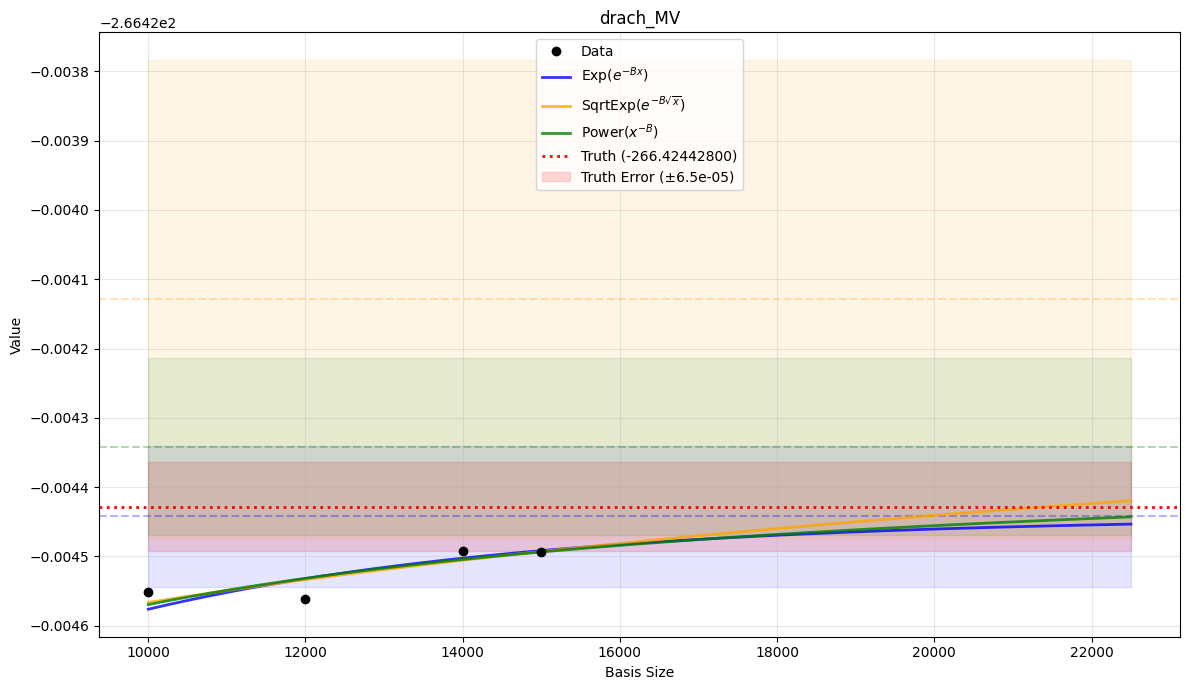

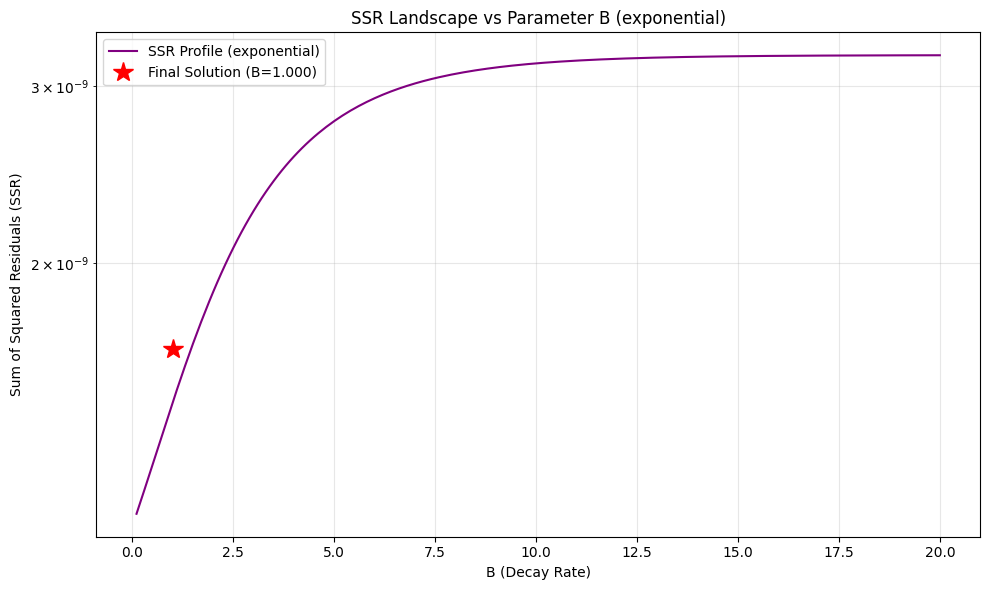

In [13]:
solver = VarProIRLS(be_3po_init, 'basis size', 'drach_MV', err_df=be_3po_err)
solver.fit_irls()
solver.plot(truth_val = -266.424427999999977)
solver.plot_ssr_profile()

In [11]:
be_3po

,basis size,Energy,MV,drach_MV,OO,SO1,SO2,delta(r_1),delta(r_12),drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12),drach_Darwin
0,10000,-14.566341470490000276,-266.384374999999977263,-266.424551000000008116,-0.755524179000000018,0.302760707999999990,-0.208909598000000002,8.714667920000000123,0.261089854000000010,8.716281052999999446,0.261076400099999995,-225.861432000000007747,-1.162322089999999974,214.102066000000007762
1,12000,-14.566341473250000504,-266.407287999999994099,-266.424561999999980344,-0.755524170000000050,0.302760866000000017,-0.208909416999999986,8.715565760000000495,0.261087612000000024,8.716281777000000730,0.261076407600000004,-225.967606999999986783,-1.162083860000000080,214.124673000000001366
2,14000,-14.566341476990000814,-266.407753000000013799,-266.424491999999986547,-0.755524199999999979,0.302760890000000005,-0.208909310999999986,8.715610079999999371,0.261080517999999984,8.716281846999999416,0.261076414899999998,-225.972520000000002938,-1.161212080000000091,214.125921000000005279
3,15000,-14.566341478800000075,-266.409592999999972562,-266.424492999999984022,-0.755524207999999975,0.302760915999999991,-0.208909149999999988,8.715677019999999331,0.261080474999999979,8.716281870999999626,0.261076417100000013,-225.981448000000000320,-1.161208629999999964,214.127603999999990947
4,20000,-14.566341480480000214,-266.410057999999992262,-266.424427999999977601,-0.755524214999999999,0.302760943000000005,-0.208908988999999989,8.715743959999999291,0.261080431999999973,8.716281893999999753,0.261076419200000021,-225.985752999999988333,-1.160956820000000000,214.129287000000005037
